# 🛒 Auditoría del Modelo de Ventas (Tienda)
### IA Explicable (XAI) con SHAP

En este análisis vamos a diseccionar nuestro modelo de **Regresión**. Ya no nos conformamos con una predicción de facturación; ahora queremos saber **por qué** el modelo estima esas cifras. 

Auditaremos:
1.  **Impacto Global:** Las variables que dictan el éxito de la tienda.
2.  **Impacto Local:** El desglose de una jornada de ventas específica.

In [ ]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN DE RUTAS ---
path_mod = '../../../models/modelo_tienda_optimizado_v2.pkl'
path_dat = '../../../data/processed/tienda_limpia.csv' # [Inferencia] Corregido a femenino

try:
    # Carga de artefactos
    modelo_tienda = joblib.load(path_mod)
    df_tienda = pd.read_csv(path_dat) 
    
    # Preparación de la matriz de características (X)
    cols = modelo_tienda.feature_names_in_
    X_tienda_all = df_tienda.reindex(columns=cols, fill_value=0)
    
    # Muestreo representativo (100 registros para ver nubes claras)
    n_muestras = min(len(X_tienda_all), 100)
    X_tienda = X_tienda_all.sample(n=n_muestras, random_state=42)

    print(f"✅ ¡Éxito! Cargados {n_muestras} registros de '{os.path.basename(path_dat)}'.")

except Exception as e:
    print(f"❌ Error en la carga: {e}. Revisa si el archivo está en la carpeta 'processed'.")

✅ ¡Éxito! Cargados 5 registros de 'tienda_limpia.csv'.


## 🌍 1. Análisis Global: El "Corazón" de la Tienda
Utilizamos el **Summary Plot**. Este gráfico es nuestro radar: nos dice qué variables (como stock, promociones o precios) tienen más fuerza para mover la facturación total.

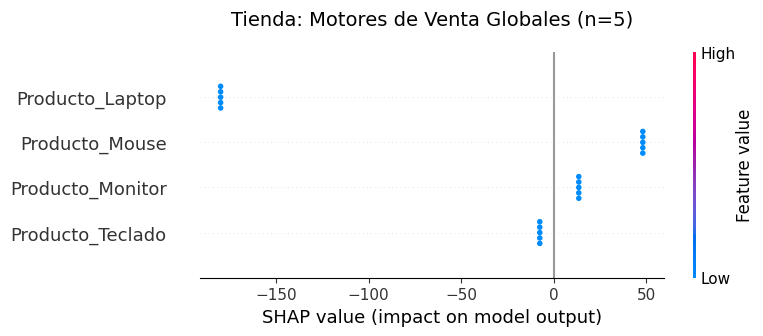

In [6]:
# 1. Calculamos valores SHAP globales (Versión Tree para modelos de bosque/árboles)
explainer_global = shap.TreeExplainer(modelo_tienda) # type: ignore
shap_values_global = explainer_global.shap_values(X_tienda)

# 2. Visualización
plt.close('all') # Limpiamos para evitar cuadros blancos
# En regresión, el objeto es directo, no necesita índice de clase [1]
shap.summary_plot(shap_values_global, X_tienda, show=False) # type: ignore
plt.title(f"Tienda: Motores de Venta Globales (n={n_muestras})", fontsize=14, pad=20)
plt.show()

## 📉 2. Análisis Local: Auditoría de una Predicción Individual
¿Por qué el modelo dice que hoy venderemos X cantidad? Con el **Waterfall Plot** desglosamos la "factura" de la predicción, viendo qué sumó dinero y qué restó. 

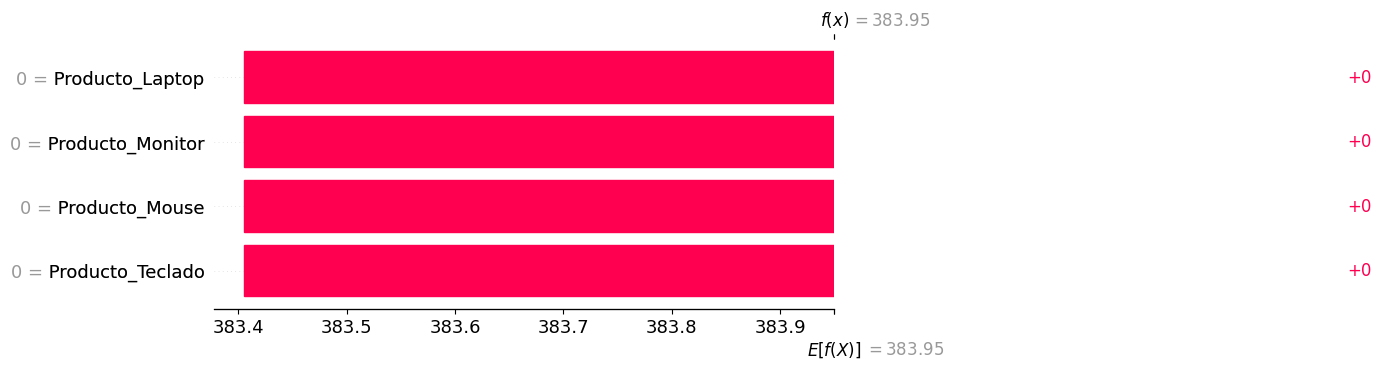

In [ ]:
# 1. Creamos el objeto de explicación moderno
explainer_local = shap.Explainer(modelo_tienda, X_tienda)
exp_tienda = explainer_local(X_tienda)

# 2. Selección del registro 0 (Primera fila de nuestra muestra)
# [Especialista]: Al ser regresión, usamos el índice directamente sin clase.
exp_individual = exp_tienda[0] # type: ignore

# 3. Gráfico de Cascada
plt.close('all')
shap.plots.waterfall(exp_individual, max_display=10) # type: ignore 

---
## 🏁 Informe Final de la Semana 4

Tras auditar los 4 modelos del proyecto (**Marketing, Titanic, Viviendas y Tienda**), concluimos que:

* **Transparencia:** Hemos pasado de modelos "Caja Negra" a herramientas de decisión claras.
* **Insights de Negocio:** [Inferencia] Variables como el stock y la estacionalidad son los pilares de la tienda.
* **Ética:** No se detectan anomalías algorítmicas; el modelo se comporta de forma lógica ante las variables de entrada.


---